# ライブラリの読み込み

In [1]:
# ライブラリ
import numpy as np
import torch
import onnxruntime as ort
import torch.nn.functional as F

from nuscenes_sample_generator import NuScenesSampleGenerator
from img_pipeline import PrepareImageInputs
from onnx_input_builder import OnnxInputBuilder
from bbox_decoder import BboxDecoder
from visualizer import Visualizer 
from util import load_config, load_json

import matplotlib.pyplot as plt

# 設定ファイルの読み込み設定

In [2]:
# パスの設定
json_path   = "bevdetv3-nuscenes_infos_val.json"
config_path = "config.yaml"

# 初期化処理

In [3]:
# jsonファイルとconfigファイルの読み込み
json_file   = load_json(json_path)
data_config = load_config(config_path)

# sample Generator
data_infos = json_file['infos']
sample_generator = NuScenesSampleGenerator(data_infos=data_infos, num_adj_frame=1)

# image pipeline
image_pipline = PrepareImageInputs(data_config["data_config"], sequential=True, opencv_pp=False)

# 入力データの作成
grid_config = data_config["geometry"]["grid_config"]
image_size  = data_config["data_config"]["input_size"]
onnx_input_builder = OnnxInputBuilder(grid_config, image_size, stride=16, accelerate=True)

# モデルの後処理
post_center_range = data_config["bbox_decoder"]["post_center_range"]
max_num           = data_config["bbox_decoder"]["max_num"]
num_classes       = data_config["bbox_decoder"]["num_classes"]
score_threshold   = data_config["bbox_decoder"]["score_threshold"]
bbox_decoder = BboxDecoder(post_center_range, max_num, num_classes, None)

# 可視化
save_path   = data_config["visualizer"]["save_path"]
save_format = data_config["visualizer"]["save_format"]
save_prefix = data_config["visualizer"]["save_prefix"]
fps         = data_config["visualizer"]["fps"]
visualizer  = Visualizer(0.5, save_path, save_format, save_prefix, fps, scale_factor=3, color_map=(0, 255, 255))

# モデルの読み込み
fastbev = ort.InferenceSession(
     "./onnx/fastbev.onnx",
    #providers=["CUDAExecutionProvider", "CPUExecutionProvider"]
    providers=["CPUExecutionProvider"]
)

fastbev4d = ort.InferenceSession(
    "./onnx/fastbev_4d.onnx",
    #providers=["CUDAExecutionProvider", "CPUExecutionProvider"]
    providers=["CPUExecutionProvider"]
)

# 推論処理

/home/kenta/fastbev/model_deploy/bbox_decoder.py:160: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.post_center_range = torch.tensor(self.post_center_range, device=scores.device)


rot: [-0.9687876119182126, -0.004506968075376869, -0.00792272203393983, 0.24772460658591755]
trans: [599.849775495386, 1647.6411294309523, 0.0]
rot_quaternion: -0.969 -0.005i -0.008j +0.248k
rot: [-0.9665742503886544, -0.003435376240753986, -0.008172037010679204, 0.25623355456846647]
trans: [603.5686081532947, 1645.5364009309958, 0.0]
rot_quaternion: -0.967 -0.003i -0.008j +0.256k
rot: [-0.9630016126779171, -0.007293922623181031, -0.0063732714955848846, 0.2693215069075283]
trans: [607.1937161040605, 1643.3740735728568, 0.0]
rot_quaternion: -0.963 -0.007i -0.006j +0.269k
rot: [-0.9589732066270943, -0.008681510671753835, -0.013608059495826637, 0.2830368192666146]
trans: [610.7307028936705, 1641.14262811905, 0.0]
rot_quaternion: -0.959 -0.009i -0.014j +0.283k
rot: [-0.9549288393514963, -0.00943297018381591, -0.02008887268528046, 0.2960040000448481]
trans: [614.1999604910318, 1638.8216910726615, 0.0]
rot_quaternion: -0.955 -0.009i -0.020j +0.296k


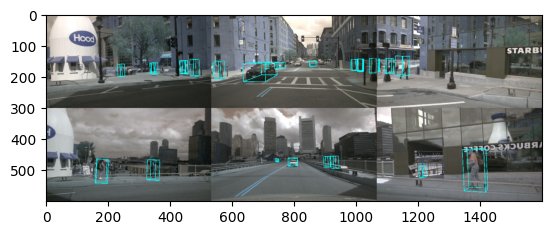

In [5]:
with torch.no_grad():
    for i in range(len(data_infos)):
        #if i<1:
        #    continue
            
        if i>=5:
            break
                
        # 入力データを過去と現在フレームに分ける(ONNX)
        input_data = sample_generator.get_data_info(i)
    
        # 前処理
        input_data = image_pipline(input_data)
        img_curr, sensor2keyegos_curr, ego2globals_curr, intrins_curr, post_rots_curr, post_trans_curr, bda_curr = input_data["img_inputs_curr"]
        img_prev, sensor2keyegos_prev, ego2globals_prev, intrins_prev, post_rots_prev, post_trans_prev, bda_prev = input_data["img_inputs_prev"]
    
        # FastBEVモデルの入力データ作成
        # 現在フレームの入力データ
        _, coors_img_curr, coors_depth_curr = onnx_input_builder.get_fastray_input(input_data["img_inputs_curr"]) # 事前計算済みの座標変換情報
        coors_img_curr, coors_depth_curr = coors_img_curr[0], coors_depth_curr[0]
        
        # 過去フレームの入力データ
        # align_after_view_transfromationの対応
        input_data["img_inputs_prev"][1] = input_data["img_inputs_curr"][1] # sensor2keyegos
        input_data["img_inputs_prev"][2] = input_data["img_inputs_curr"][2] # ego2global
        _, coors_img_prev, coors_depth_prev = onnx_input_builder.get_fastray_input(input_data["img_inputs_prev"]) # 事前計算済みの座標変換情報
        coors_img_prev, coors_depth_prev = coors_img_prev[0], coors_depth_prev[0]

        # BEV特徴量の作成
        bev_feat_curr_onnx = fastbev.run(
            ["bev_feat"],
            {
                "img": img_curr.squeeze(0).cpu().numpy().astype(np.float32),
                "coors_img": coors_img_curr.cpu().numpy().astype(np.int64),
                "coors_depth": coors_depth_curr.cpu().numpy().astype(np.int64),
            }
        )[0] # 現在フレーム
               
        bev_feat_prev_onnx = fastbev.run(
            ["bev_feat"],
            {
                "img": img_prev.squeeze(0).cpu().numpy().astype(np.float32),
                "coors_img": coors_img_prev.cpu().numpy().astype(np.int64),
                "coors_depth": coors_depth_prev.cpu().numpy().astype(np.int64),
            }
        )[0] # 過去フレーム

        # 後段の処理のために、一旦torchに戻す
        bev_feat_curr = torch.from_numpy(bev_feat_curr_onnx).float()
        bev_feat_prev = torch.from_numpy(bev_feat_prev_onnx).float()
            
        # BEVの結合
        bev_feat_list = [bev_feat_curr, bev_feat_prev]
        bev_feat_list[1] = onnx_input_builder.shift_feature(bev_feat_list[1], [sensor2keyegos_curr, sensor2keyegos_prev], bda_curr)
        bev_feats = torch.cat(bev_feat_list, dim=1)

        # 物体認識
        detections = fastbev4d.run(
            None,
            {"bev_feats": bev_feats.cpu().numpy()}
        )
        
        # 後処理
        detections = [torch.from_numpy(detection).float() for detection in detections] # torchに戻す
        bboxes, scores, labels = bbox_decoder.get_bbox(detections)
    
        # 可視化
        nusc_results, nusc_annos = visualizer.format_bbox(bboxes, scores, labels, data_infos[i]) # nuscenesに座標変換        
        drawed_img = visualizer.draw_bbox(nusc_results, data_infos[i], i)
        
        plt.imshow(drawed_img)